In [185]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm



In [197]:
# import funcs

%run ./utils.ipynb

In [193]:
source = '/cosma5/data/durham/dc-pick2/simulations/'
hyades_path = source + '/Hyades'
orbit_path = hyades_path + '/orbit.csv'

snapshots = [0, 60, 120, 180, 240]


In [194]:
orbit_df = pd.read_csv(orbit_path)

orbit_df['RG'] = np.sqrt(df['RGx']**2 + df['RGy']**2 + df['RGz']**2)

orbit_df

,T,RGx,RGy,RGz,VGx,VGy,VGz,JZ,ET,RG
0,0.000000,-1.760000,11.370000,0.110000,143.300000,2.400000,0.700000,-288070.060398,0.000000,11.505938
1,4.819376,-1.048345,11.341873,0.098368,145.309362,-13.864964,-5.384619,-288070.060398,-0.000944,11.390644
2,9.638751,-0.329208,11.232785,0.058226,146.319102,-30.454904,-10.634601,-288070.060398,0.794992,11.237759
3,14.458127,0.392300,11.041109,-0.001652,146.267898,-47.375080,-12.922355,-288070.060398,3.629713,11.048076
4,19.277502,1.110784,10.765321,-0.060729,145.078719,-64.572506,-10.268684,-288070.060398,8.714572,10.822646
...,...,...,...,...,...,...,...,...,...,...
126,607.241325,-0.731962,10.563830,0.049973,157.658347,-43.623777,11.270696,-288070.060398,109.405560,10.589276
127,612.060700,0.047089,10.304175,0.092150,158.249858,-61.814856,5.385190,-288070.060398,108.079036,10.304694
128,616.880076,0.825689,9.953776,0.100283,157.440477,-80.439213,-2.224171,-288070.060398,106.726712,9.988467
129,621.699452,1.596557,9.510521,0.070242,155.062343,-99.477372,-9.780530,-288070.060398,103.553842,9.643855


In [192]:
df_glob = get_glob_df(source)
df_glob

/tmp/ipykernel_1085565/3304288765.py:20: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


,TIME[NB},TIME[Myr],TCR[Myr],DE,BE(3),RSCALE[PC],RTIDE[PC],RDENS[PC],RC[PC],RHOD[M*],...,NKSTRY,NKSREG,NKSHYP,NKSPER,NKSMODNTTRY,NTRIP,NQUAD,NCHAIN,NMERG,NEWHI
0,0.0,0.000000,6.815626,0.000000e+00,-0.250000,2.955255,29.552546,0.234807,0.958058,818.069811,...,0,0,0,0,0,0,0,0,0,0
1,2.0,4.819376,0.011955,1.360279e-05,-0.317480,3.028262,30.282619,0.164241,0.330994,9834.503833,...,3106,13,7,0,0,0,0,0,0,0
2,4.0,9.638751,0.001771,3.043003e-05,-0.395085,3.196056,31.960562,3.878489,0.603697,1277.381308,...,600,6,6,0,0,0,0,0,0,0
3,6.0,14.458127,0.000241,2.048990e-05,-0.454839,3.440855,34.408552,6.358898,0.973610,645.092759,...,383,2,2,0,0,0,0,0,0,0
4,8.0,19.277502,0.000178,-4.026449e-06,-0.503868,3.366604,33.666039,8.210033,1.429130,298.514606,...,594,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,252.0,607.241325,0.000115,3.238658e-07,-33.429079,28.877451,288.774513,1166.008292,0.481349,308660.831899,...,209,0,0,0,56,0,0,0,0,0
127,254.0,612.060700,0.000115,9.239450e-06,-34.023319,28.411962,284.119617,1157.988048,0.256884,625246.983055,...,49805,4,1,0,20,0,0,0,0,0
128,256.0,616.880076,0.000114,8.932158e-06,-34.640320,29.013190,290.131899,1149.040661,1.018214,39386.330282,...,148634,0,0,0,0,0,0,0,0,0
129,258.0,621.699452,0.000112,2.375695e-05,-35.400953,38.506792,385.067920,1139.071223,1.760028,31147.595308,...,64425,3,0,0,48,0,0,0,0,0


In [ ]:
for i, snap in enumerate(snapshots):
    path = source + f'/snap.40_{snap}.h5part'
    
    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

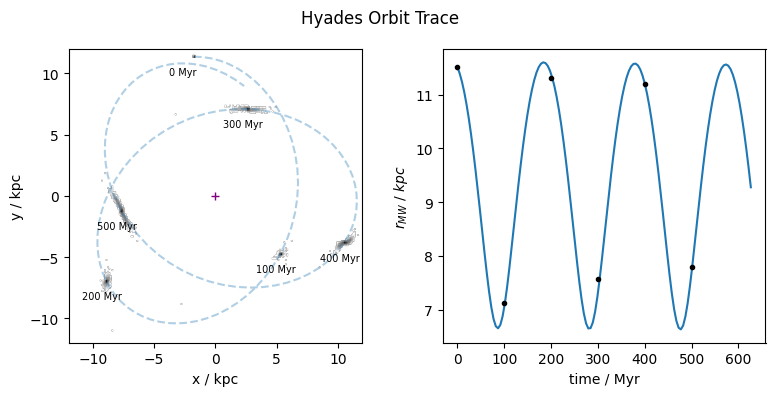

In [223]:
xmin, xmax = -12, 12
ymin, ymax = -12, 12

zoom = 5

times = [0, 100, 200, 300, 400, 500]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

snap_times = []
snap_idx = []

density = np.zeros((bins, bins))

run = 'Hyades'
Hyades_path = source + '/Hyades'
snaps = get_snaps(Hyades_path)
snap_df = get_run_snap_times('Hyades', snaps, df_glob)
timesdf = find_times_Myr(snap_df, run, times)

for i, row in timesdf.iterrows():

    Myr_per_Nbody = 1 if row['Time[NB]'] == 0 else row['Time[Myr]'] / row['Time[NB]']
    stepdf = get_step(row['snap_path'], row['Step'], Myr_per_Nbody)

    t = stepdf.attrs['Time']
    
    idx = np.searchsorted(orbit_df['T'], t)
    galx = orbit_df['RGx'][idx]
    galy = orbit_df['RGy'][idx]

    zoomx = stepdf['X'] / 1000 * zoom
    zoomy = stepdf['Y'] / 1000 * zoom

    com_x = np.median(zoomx)
    com_y = np.median(zoomy)

    hist, _, _ = np.histogram2d(zoomx - com_x + galx, zoomy - com_y + galy,
                                bins=200, 
                                range=[[xmin, xmax],
                                       [ymin, ymax]])

    density += hist

    

    ax[0].text(galx - 2, galy - 1.5, f"{t:.0f} Myr", fontsize=7)
    
    ax[1].plot(t,orbit_df['RG'][idx], marker='.', color='black', zorder=10)


ax[0].imshow(density.T, origin='lower', 
             extent=[xmin, xmax, ymin, ymax],
             cmap='gray_r', norm=LogNorm()
)

ax[0].plot(df['RGx'], df['RGy'], linestyle='dashed', alpha=0.35, color='tab:blue')
ax[0].plot(0, 0, marker='+', color='purple', linestyle='')


ax[0].set_xlim([xmin, xmax])
ax[0].set_ylim([ymin, ymax])
ax[0].set_aspect('equal')
ax[0].set_xlabel("x / kpc")
ax[0].set_ylabel("y / kpc")

ax[1].plot(df['T'], df['RG'],  color='tab:blue')
ax[1].set_xlabel('time / Myr')
ax[1].set_ylabel(r'$r_{MW}\ /\ kpc$')

plt.suptitle('Hyades Orbit Trace')
plt.savefig('Images/HyadesOrbit.png')
plt.tight_layout()
plt.show()